In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time as time_module

# Simulation engine + diagnostics come from the installed `wisp` package.
# Run `pip install -e .` from the repo root once so these imports resolve.
from wisp.core import run_timestepping
from wisp.diagnostics import compute_gamma, fit_gamma


In [2]:
# ── Parameters ─────────────────────────────────────────────────────────────
# Baseline configuration for the plasma simulation.
# These values are used for every run unless overwritten by the loop.
base = {
    "E_c": 1e-12,         # Start with a tiny field to stay in the linear growth regime
    "E_s": 0.0,
    "nb_over_ne": 5e-7,   # Physical beam-to-plasma density ratio
    "ub": 1.05,           # Beam drift velocity
    "vb": 0.5,            # Beam thermal velocity
    "seed": 1,            # Lock the seed to ensure particle noise is identical across runs
    "method": "linear",   # Use the linearized particle pusher
    "full_f": False,      # Delta-f simulation mode
    "splitting_method": "strang", 
    "dt": 0.1,
    "n_steps": 2000,
}

# Study variable: we sweep across time steps (at a single particle count) to check convergence
particle_counts   = [50000]
dt_list           = [1.6, 0.8, 0.4, 0.2, 0.1, 0.05, 0.025] # Coarse steps for x-axis
dt_ref            = 0.005                                  # High-res "truth" step
splitting_methods = ["trotter", "strang"]                  # Methods being compared
T_end             = 200.0                                  # Total simulation time
fit_window        = (20.0, 120.0)                          # Time range used to measure growth rate

# Calculate the analytical (theoretical) growth rate for comparison
gamma_an = compute_gamma(base)

# Workload calculations: determines how many total simulations will be performed
n_ref_runs   = len(particle_counts) * len(splitting_methods)
n_sweep_runs = len(particle_counts) * len(dt_list) * len(splitting_methods)

# Print a summary of the study parameters to the console
print(f"Analytic gamma = {gamma_an:.6e}")
print(f"Particle counts: {particle_counts}")
print(f"Reference dt   = {dt_ref}  ({int(T_end/dt_ref):,} steps per ref run)")
print(f"Sweep dt list  = {dt_list}")
print(f"Reference runs = {n_ref_runs}")
print(f"Sweep runs     = {n_sweep_runs}")
print(f"Total runs     = {n_ref_runs + n_sweep_runs}")

Analytic gamma = 3.509635e-07
Particle counts: [50000]
Reference dt   = 0.005  (40,000 steps per ref run)
Sweep dt list  = [1.6, 0.8, 0.4, 0.2, 0.1, 0.05, 0.025]
Reference runs = 2
Sweep runs     = 14
Total runs     = 16


In [3]:
# ── Step 1: Compute high-resolution reference values ───────────────────────
# We need a "ground truth" to measure our errors against. 
# We'll run simulations at a very tiny dt (0.005) so we can assume 
# these results are the "correct" numerical answers.
gamma_ref = {n: {} for n in particle_counts}

print(f"Computing reference gammas at dt={dt_ref}...\n")
print(f"{'n_particles':>12}  {'method':>8}  {'gamma_ref':>14}  {'vs analytic':>12}  {'time':>6}")
print("-" * 60)

for n in particle_counts:
    for method in splitting_methods:
        # Create the high-res parameter set for this specific run
        sp = dict(base)
        sp["n_particles"]      = n
        sp["dt"]               = float(dt_ref)      # Use the tiny reference time-step
        sp["splitting_method"] = method
        sp["n_steps"]          = int(np.round(T_end / dt_ref))

        # Run the simulation. Since dt is so small, these take the longest to finish.
        t0      = time_module.time()
        out     = run_timestepping(sp)
        elapsed = time_module.time() - t0

        # Calculate the growth rate (gamma) from the electric field data
        # We look specifically inside the 'fit_window' (t=20 to t=120)
        g = fit_gamma(out["time"], out["E_amp_hist"], fit_window[0], fit_window[1])
        
        # Save this value so we can subtract it from our coarse runs later
        gamma_ref[n][method] = g

        # Print a progress row. The 'vs analytic' column is just a sanity check 
        # to make sure the physics hasn't completely blown up.
        print(f"{n:>12,}  {method:>8}  {g:>14.6e}  {abs(g-gamma_an):>12.3e}  {elapsed:>5.1f}s")

print("\nReference gammas done.")

Computing reference gammas at dt=0.005...

 n_particles    method       gamma_ref   vs analytic    time
------------------------------------------------------------
      50,000   trotter    3.504405e-07     5.230e-10  102.8s
      50,000    strang    3.493322e-07     1.631e-09  157.3s

Reference gammas done.


In [4]:
# ── Step 2: Convergence sweep ──────────────────────────────────────────────
# We initialize a results dictionary to store the dt, growth rate, and 
# calculated error for every single combination of resolution and method.
results = {
    n: {m: {"dt": [], "gamma_fit": [], "error": []}
        for m in splitting_methods}
    for n in particle_counts
}

run_count   = 0
sweep_start = time_module.time()

# Primary Loop: Iterate through different particle resolutions
for n in particle_counts:
    print(f"\n{'='*60}")
    print(f"n_particles = {n:,}")
    print(f"{'='*60}")

    # Secondary Loop: Test both Trotter and Strang splitting methods
    for method in splitting_methods:
        # Pull the 'ground truth' reference value we calculated in Step 1
        g_ref = gamma_ref[n][method]
        print(f"  --- {method.upper()}  (gamma_ref = {g_ref:.6e}) ---")

        # Tertiary Loop: Run simulations for each time-step size in our list
        for dt in dt_list:
            # Configure parameters for this specific coarse run
            sp = dict(base)
            sp["n_particles"]      = n
            sp["dt"]               = float(dt)
            sp["splitting_method"] = method
            sp["n_steps"]          = int(np.round(T_end / dt))

            # Run the simulation engine
            t0      = time_module.time()
            out     = run_timestepping(sp)
            elapsed = time_module.time() - t0

            # Measure the growth rate of this coarse simulation
            g_fit = fit_gamma(out["time"], out["E_amp_hist"],
                              fit_window[0], fit_window[1])
            
            # The heart of the study: Calculate the absolute error 
            # relative to the high-resolution reference run.
            err = abs(g_fit - g_ref)

            # Store the data for the final log-log plotting cells
            results[n][method]["dt"].append(dt)
            results[n][method]["gamma_fit"].append(g_fit)
            results[n][method]["error"].append(err)

            # Performance tracking: Calculate total progress and estimated time remaining
            run_count += 1
            elapsed_total = time_module.time() - sweep_start
            eta = elapsed_total / run_count * (n_sweep_runs - run_count)
            print(f"    dt={dt:<5g}  err={err:.3e}  ({elapsed:.1f}s)  "
                  f"[{run_count}/{n_sweep_runs}, ETA {eta/60:.1f} min]")

print(f"\nSweep total: {(time_module.time()-sweep_start)/60:.1f} minutes")


n_particles = 50,000
  --- TROTTER  (gamma_ref = 3.504405e-07) ---
    dt=1.6    err=1.984e-07  (0.2s)  [1/14, ETA 0.0 min]
    dt=0.8    err=9.888e-08  (0.4s)  [2/14, ETA 0.1 min]
    dt=0.4    err=4.913e-08  (0.9s)  [3/14, ETA 0.1 min]
    dt=0.2    err=2.426e-08  (2.3s)  [4/14, ETA 0.2 min]
    dt=0.1    err=1.182e-08  (3.9s)  [5/14, ETA 0.2 min]
    dt=0.05   err=5.598e-09  (7.7s)  [6/14, ETA 0.3 min]
    dt=0.025  err=2.488e-09  (13.4s)  [7/14, ETA 0.5 min]
  --- STRANG  (gamma_ref = 3.493322e-07) ---
    dt=1.6    err=6.850e-08  (0.5s)  [8/14, ETA 0.4 min]
    dt=0.8    err=1.830e-08  (0.9s)  [9/14, ETA 0.3 min]
    dt=0.4    err=4.667e-09  (1.5s)  [10/14, ETA 0.2 min]
    dt=0.2    err=1.180e-09  (3.1s)  [11/14, ETA 0.2 min]
    dt=0.1    err=2.991e-10  (6.1s)  [12/14, ETA 0.1 min]
    dt=0.05   err=7.627e-11  (12.8s)  [13/14, ETA 0.1 min]
    dt=0.025  err=1.935e-11  (24.7s)  [14/14, ETA 0.0 min]

Sweep total: 1.3 minutes


In [5]:
# ── Sort by dt ascending ───────────────────────────────────────────────────
# During the sweep, data might be collected in any order. To make sure our 
# plots look correct and our slope-fitting logic works, we sort the 
# results for each (n, method) pair by the time-step size (dt).
for n in particle_counts:
    for m in splitting_methods:
        # Get the indices that would sort the 'dt' list from smallest to largest
        idx = np.argsort(results[n][m]["dt"])
        
        # Apply that same sorted order to all lists in the dictionary 
        # (dt, gamma_fit, and error) so the data points stay synchronized.
        for k in results[n][m]:
            # Convert to a numpy array to use index-shuffling, then back to a list
            results[n][m][k] = list(np.array(results[n][m][k])[idx])

In [6]:
# ── Slope estimation ───────────────────────────────────────────────────────
# This function calculates the order of convergence (p) by finding the slope 
# of the error on a log-log scale. We expect Error = C * (dt)^p.
def estimate_slope(dt_vals, err_vals, n_tail=3):
    # Filter out any non-positive error values to avoid math errors with logarithms
    pairs = [(d, e) for d, e in zip(dt_vals, err_vals) if e > 0]
    
    # We need at least two points to calculate a slope
    if len(pairs) < 2:
        return float("nan")
    
    # Transform data to log-log space: ln(Error) = p * ln(dt) + ln(C)
    # We only fit the 'n_tail' smallest dt values because the true 
    # asymptotic convergence rate is most visible as dt approaches zero.
    x = np.log(np.array([p[0] for p in pairs])[-n_tail:])
    y = np.log(np.array([p[1] for p in pairs])[-n_tail:])
    
    # Perform a linear regression (1st degree polynomial) in log-log space.
    # The first coefficient [0] is the slope, which represents the convergence order.
    return np.polyfit(x, y, 1)[0]

# Print a formatted table to summarize the results
print(f"{'n_particles':>12}  {'method':>8}  {'slope':>7}  (expect Trotter~1, Strang~2)")
print("-" * 45)

for n in particle_counts:
    for m in splitting_methods:
        # Calculate the slope for this specific configuration
        slope = estimate_slope(results[n][m]["dt"], results[n][m]["error"])
        
        # Display the result (e.g., 1.00 for Trotter, 2.00 for Strang)
        print(f"{n:>12,}  {m:>8}  {slope:>7.2f}")

 n_particles    method    slope  (expect Trotter~1, Strang~2)
---------------------------------------------
      50,000   trotter     1.01
      50,000    strang     1.94


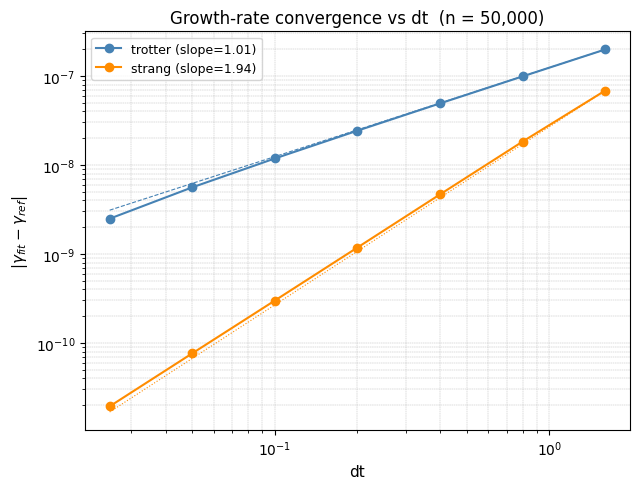

Saved: convergence_sweep_50k.png


In [7]:
# ── Plot: convergence of growth-rate error vs dt ───────────────────────
n = particle_counts[0]   # single particle count for this example

fig, ax = plt.subplots(figsize=(6.5, 5))
colors  = {"trotter": "steelblue", "strang": "darkorange"}
dt_plot = np.array([min(dt_list), max(dt_list)])

for m in splitting_methods:
    dtv   = np.array(results[n][m]["dt"])
    errv  = np.array(results[n][m]["error"])
    slope = estimate_slope(results[n][m]["dt"], results[n][m]["error"])
    ax.loglog(dtv, errv, marker="o", color=colors[m],
              label=f"{m} (slope={slope:.2f})")

# Reference guide lines: 1st-order (Trotter) and 2nd-order (Strang)
for m, order, ls in [("trotter", 1, "--"), ("strang", 2, ":")]:
    err0 = results[n][m]["error"][-1]
    dt0  = results[n][m]["dt"][-1]
    ax.loglog(dt_plot, err0 * (dt_plot / dt0)**order,
              color=colors[m], linestyle=ls, lw=0.8)

ax.set_title(f"Growth-rate convergence vs dt  (n = {n:,})", fontsize=12)
ax.set_xlabel("dt", fontsize=11)
ax.set_ylabel(r"$|\gamma_{fit} - \gamma_{ref}|$", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which="both", linestyle="--", linewidth=0.3)

plt.tight_layout()
plt.savefig("convergence_sweep_50k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: convergence_sweep_50k.png")
